# Density Peak Clustering on the Old Faithful Dataset

This notebook compares the original DPC, GGDPC, DPC-KNN-PCA, SNN-DPC, DPC-CE, DPC-DLP, and DPC-MDNN. The comparison-method parameters follow Table 5 of Wang et al. (2025) (https://www.nature.com/articles/s41598-025-92509-4), and the known number of Old Faithful clusters is four.

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram

from GGDPC import DPC, GGDPC
from DPC_variants import DPC_KNN_PCA, SNN_DPC, DPC_CE, DPC_DLP, DPC_MDNN

results = {}

def plot_clustering(X, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=20)
    if len(centers):
        plt.scatter(X[centers, 0], X[centers, 1], c="red", marker="X", s=90,
                    label="Cluster Centers")
        plt.legend()
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    # plt.axis("equal")
    plt.show()

def record_result(name, true_labels, pred_labels, elapsed):
    ari = adjusted_rand_score(true_labels, pred_labels)
    results[name] = {
        "Method": name,
        "ARI": ari,
        "Clusters Found": np.unique(pred_labels[pred_labels != -1]).size,
        "Noise Points": np.sum(pred_labels == -1),
        "Runtime (s)": elapsed}
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Runtime: {elapsed:.3f} seconds")

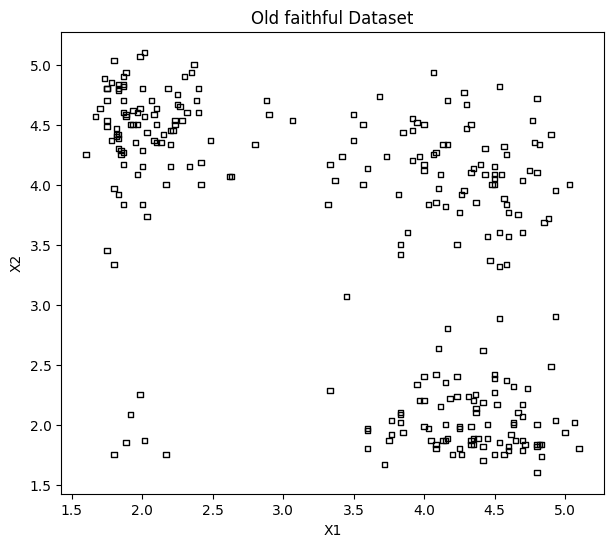

In [4]:
import statsmodels.api as sm

# Load the built-in dataset
dataset = sm.datasets.get_rdataset("faithful", "datasets")
df = dataset.data
dat = pd.DataFrame({
    "current": df["eruptions"].iloc[:-1].to_numpy(),
    "next": df["eruptions"].iloc[1:].to_numpy()
})
X_dat = np.column_stack([dat['current'].values, dat['next'].values])
# X_dat = df[["eruptions", "waiting"]].to_numpy()
n_clusters = 4

plt.figure(figsize=(7, 6))
plt.scatter(X_dat[:, 0], X_dat[:, 1], marker="s", facecolors="none",
            edgecolors="black", s=15)
plt.title("Old faithful Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### Traditional DPC

The existing implementation automatically identifies centers using its default three-standard-deviation rule.

In [5]:
from matplotlib.collections import LineCollection

def plot_clusters(X, clu, start, end, centers, directed=False, title=None, figsize=(7, 6), save_path=None):
    plt.figure(figsize=figsize)
    segments = np.stack([X[start], X[end]], axis=1)

    # plot all nodes
    pts = np.vstack([X[start], X[end]])
    plt.scatter(X[:, 0], X[:, 1], c=clu, cmap='viridis', s=30)
    plt.scatter(X[centers, 0], X[centers, 1], c='red', marker='X', s=70, label='Cluster centers')
    if directed:
        plt.quiver(X[start, 0], X[start, 1], X[end, 0] - X[start, 0], X[end, 1] - X[start, 1], 
                   angles='xy', scale_units='xy', scale=1, color='black', width=0.0025, alpha=0.6)
    else:
        lc = LineCollection(segments, colors="black", linewidths=1, alpha=0.6, width=0.0025)
        plt.gca().add_collection(lc)

    plt.legend(loc='upper right', fontsize=12)
    plt.title(title)
    plt.xlabel("Current eruption duration (minutes)")
    plt.ylabel("Next eruption duration (minutes)")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

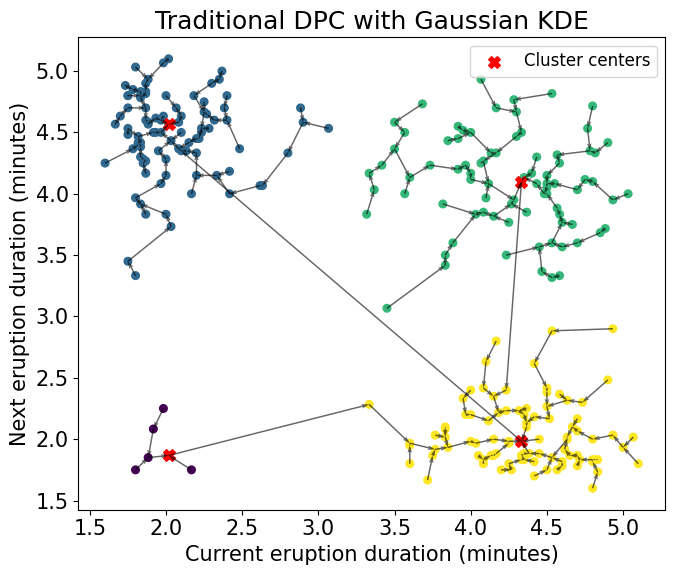

In [6]:
start = time.perf_counter()
h = None
DPC_labels, DPC_det = DPC(X_dat, den_est=None, dist_mat=None, bandwidth=h, den_thres=0, center_quantile=None,
                          scaling=False, return_details=True)
elapsed = time.perf_counter() - start

# plot_clustering(X_dat, DPC_labels, DPC_det["cluster_centers"],
#                 "Traditional DPC Clustering With Gaussian KDE")
plt.matplotlib.rcParams.update({
    "font.size": 15,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
plot_clusters(X_dat, DPC_labels, np.arange(X_dat.shape[0])[DPC_det['1nn_higher'] != -1], 
              DPC_det['1nn_higher'][DPC_det['1nn_higher'] != -1], DPC_det['cluster_centers'], directed=True,
              title="Traditional DPC with Gaussian KDE", figsize=(7, 6), 
              save_path="./Figures/DPC_faithful.pdf")
# record_result("DPC", true_labels, DPC_labels, elapsed)

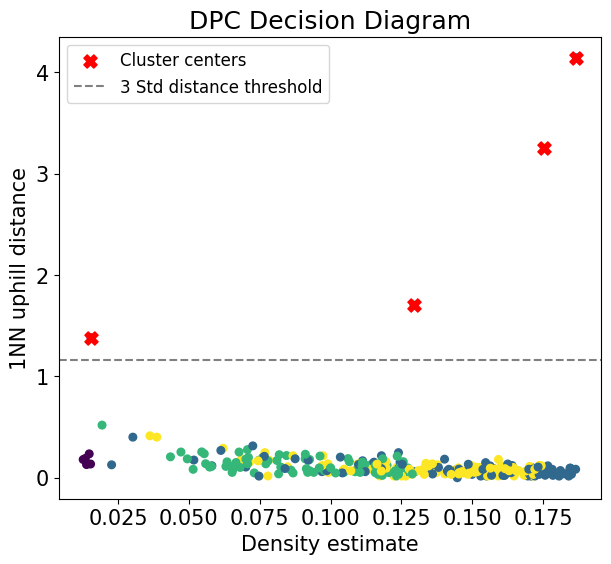

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(DPC_det["den_est"], DPC_det["delta"], c=DPC_labels,
            cmap="viridis", s=30)
plt.scatter(DPC_det["den_est"][DPC_det["cluster_centers"]], DPC_det["delta"][DPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster centers")
plt.axhline(y=3*np.std(DPC_det['delta']) + np.mean(DPC_det['delta']), color='grey', linestyle='dashed', 
            label='3 Std distance threshold')
plt.title("DPC Decision Diagram")
plt.xlabel("Density estimate")
plt.ylabel("1NN uphill distance")
plt.legend(fontsize=12)
plt.show()

### GGDPC

GGDPC uses the one-step Gaussian mean-shift location to guide the nearest-higher-density link.

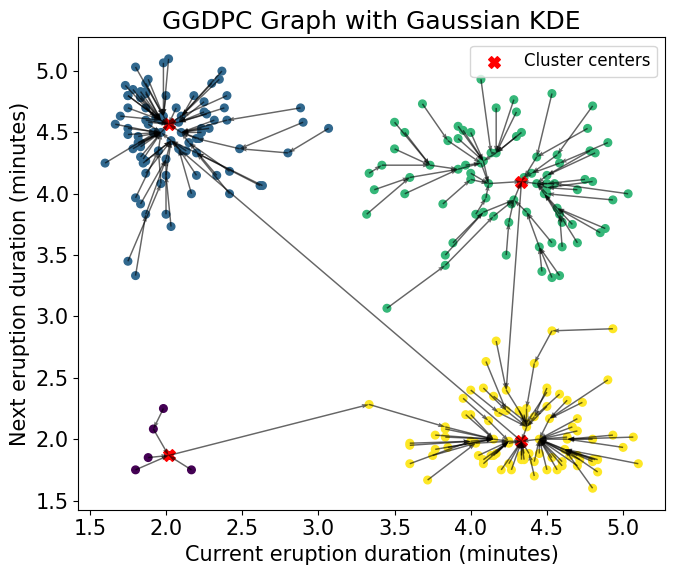

In [8]:
start = time.perf_counter()
h = None
GGDPC_labels, GGDPC_det = GGDPC(X_dat, den_est=None, grad_new=None, den_thres=0, h_den=h, h_grad=h,
                                center_quantile=None, scaling=False, return_details=True, graph_dist=True, dendro=True)
elapsed = time.perf_counter() - start

# plot_clustering(X_dat, GGDPC_labels, GGDPC_det["cluster_centers"],
#                 "GGDPC Clustering With Gaussian KDE")
plot_clusters(X_dat, GGDPC_labels, np.arange(X_dat.shape[0])[GGDPC_det['gg1nn_higher'] != -1], 
              GGDPC_det['gg1nn_higher'][GGDPC_det['gg1nn_higher'] != -1], GGDPC_det['cluster_centers'], 
              directed=True, title='GGDPC Graph with Gaussian KDE', figsize=(7, 6), 
              save_path="./Figures/GGDPC_faithful.pdf")
# record_result("GGDPC", true_labels, GGDPC_labels, elapsed)

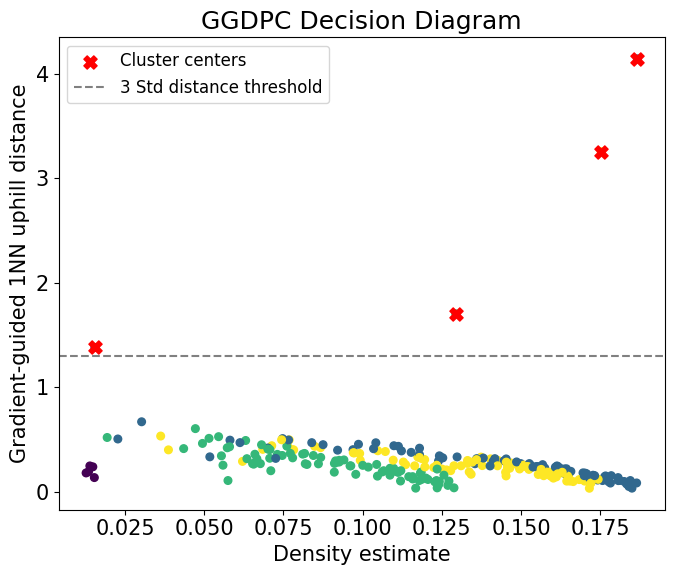

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(GGDPC_det["den_est"], GGDPC_det["delta"], c=GGDPC_labels,
            cmap="viridis", s=30)
plt.scatter(GGDPC_det["den_est"][GGDPC_det["cluster_centers"]], GGDPC_det["delta"][GGDPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster centers")
plt.axhline(y=3*np.std(GGDPC_det['delta']) + np.mean(GGDPC_det['delta']), color='grey', linestyle='dashed', 
            label='3 Std distance threshold')
plt.title("GGDPC Decision Diagram")
plt.xlabel("Density estimate")
plt.ylabel("Gradient-guided 1NN uphill distance")
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig("./Figures/GGDPC_decision_graph_faithful.pdf")

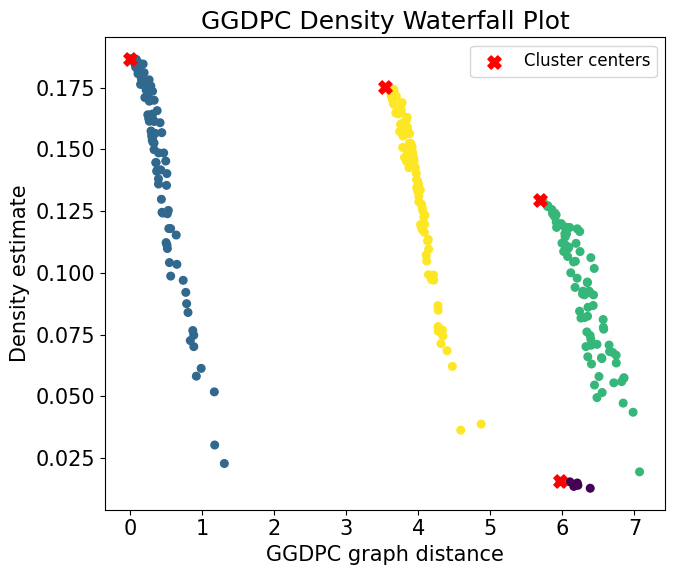

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(GGDPC_det["graph_dist"],GGDPC_det["den_est"], c=GGDPC_labels, cmap="viridis", s=30)
plt.scatter(GGDPC_det["graph_dist"][GGDPC_det["cluster_centers"]], GGDPC_det["den_est"][GGDPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster centers")
plt.title("GGDPC Density Waterfall Plot")
plt.ylabel("Density estimate")
plt.xlabel("GGDPC graph distance")
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("./Figures/GGDPC_density_waterfall_faithful.pdf")

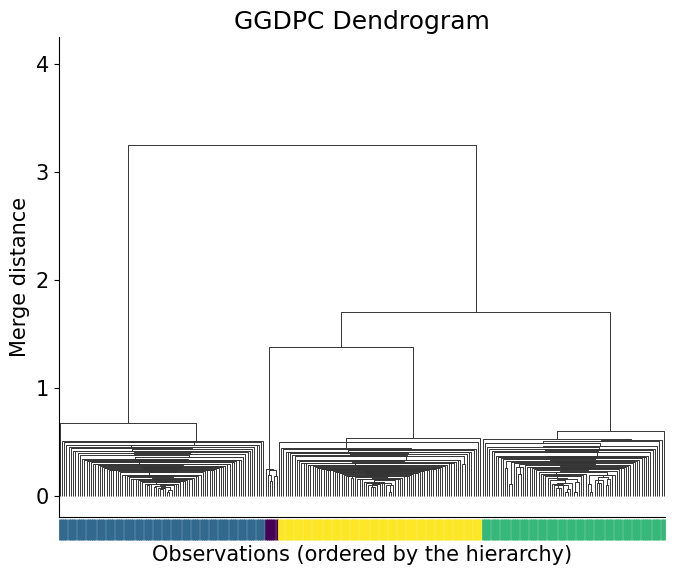

In [11]:
Z = GGDPC_det["dendrogram"]
labels = np.asarray(GGDPC_labels)

fig, ax = plt.subplots(figsize=(7, 6))

tree = dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color="#343434")

for branches in ax.collections:
    branches.set_linewidth(0.7)

# # Add a short vertical stem above the root of the dendrogram
# root_x = (tree["icoord"][-1][1] + tree["icoord"][-1][2]) / 2
# root_y = tree["dcoord"][-1][1]

# ax.plot([root_x, root_x], [root_y, root_y + 0.5], color="#343434", linewidth=0.7)

# Add cluster colors in dendrogram leaf order
ordered_labels = labels[tree["leaves"]]
# palette = plt.get_cmap("tab10")
# color_map = {
#     label: palette(i % 10)
#     for i, label in enumerate(np.unique(labels))
# }

leaf_positions = np.arange(5, 10 * len(labels) + 5, 10)

ax.scatter(leaf_positions, np.full(len(labels), -0.025),
    # c=[color_map[label] for label in ordered_labels],
    c=ordered_labels,
    cmap="viridis",
    vmin=labels.min(),
    vmax=labels.max(),
    marker="|",
    s=230,
    linewidths=2,
    transform=ax.get_xaxis_transform(),
    clip_on=False)

ax.set_title("GGDPC Dendrogram")
ax.set_xlabel("Observations (ordered by the hierarchy)", labelpad=20)
ax.set_ylabel("Merge distance")
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_ylim(-0.2, 4.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.savefig("./Figures/GGDPC_dendrogram_faithful.pdf")

### DPC-KNN-PCA

We use `k=8`. Both principal components are retained because this dataset is two-dimensional.

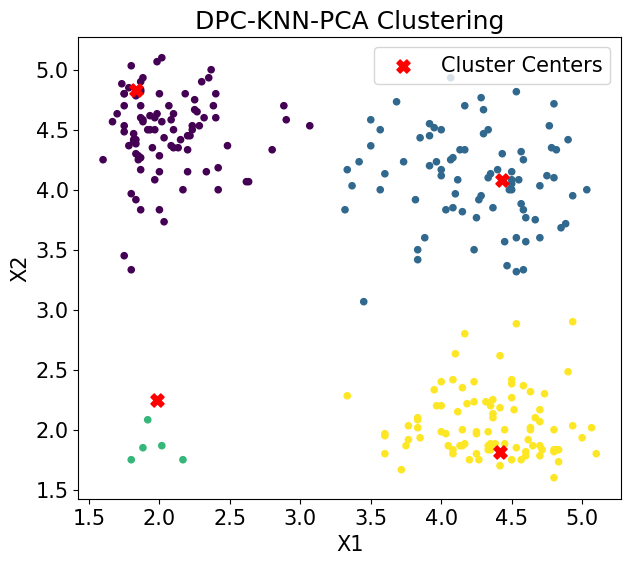

In [12]:
start = time.perf_counter()
DPC_KNN_PCA_labels, DPC_KNN_PCA_det = DPC_KNN_PCA(
    X_dat, n_clusters=n_clusters, k=8, n_components=2, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_KNN_PCA_labels, DPC_KNN_PCA_det["cluster_centers"],
                "DPC-KNN-PCA Clustering")

### SNN-DPC

We use `k=4`. Min-max scaling follows the released SNN-DPC runner.

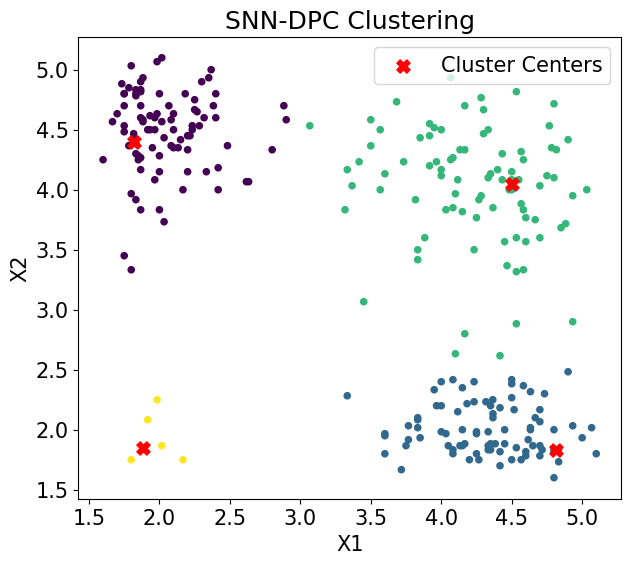

In [13]:
start = time.perf_counter()
SNN_DPC_labels, SNN_DPC_det = SNN_DPC(
    X_dat, n_clusters=n_clusters, k=4, scale=True, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, SNN_DPC_labels, SNN_DPC_det["cluster_centers"],
                "SNN-DPC Clustering")
# record_result("SNN-DPC", true_labels, SNN_DPC_labels, elapsed)

### DPC-CE

We use $d_c=2\%$, $T_r=0.25$, and $P_r=0.3$. The known cluster count replaces the MATLAB code's interactive rectangle selection.

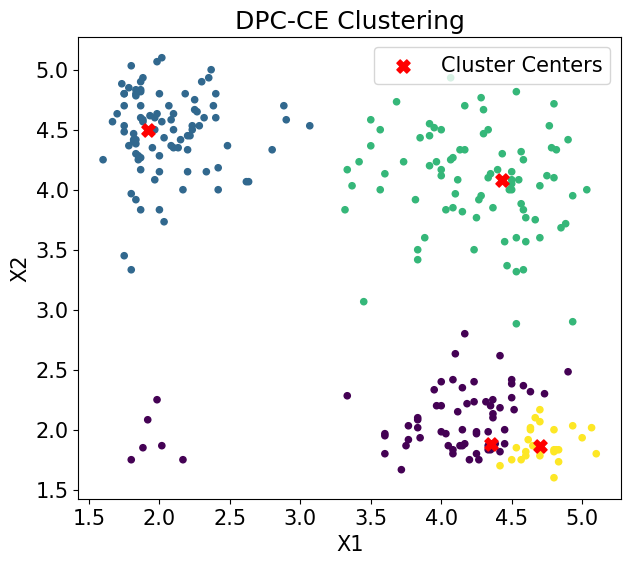

In [14]:
start = time.perf_counter()
DPC_CE_labels, DPC_CE_det = DPC_CE(
    X_dat, n_clusters=n_clusters, dc_percent=2.0, path_distance_ratio=0.25,
    distance_penalty_ratio=0.3, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_CE_labels, DPC_CE_det["cluster_centers"],
                "DPC-CE Clustering")
# record_result("DPC-CE", true_labels, DPC_CE_labels, elapsed)

### DPC-DLP

We use $p=0.9\%=0.009$. The remaining propagation settings follow the authors' released MATLAB implementation.

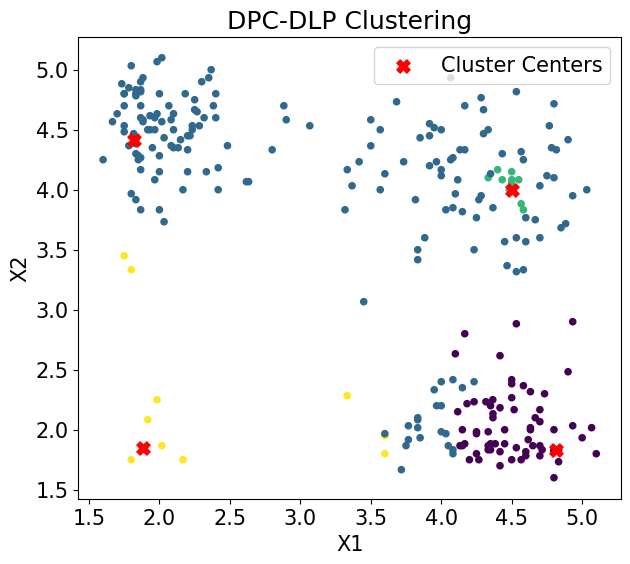

In [15]:
start = time.perf_counter()
DPC_DLP_labels, DPC_DLP_det = DPC_DLP(
    X_dat, n_clusters=n_clusters, neighbor_fraction=0.009,
    return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_DLP_labels, DPC_DLP_det["cluster_centers"],
                "DPC-DLP Clustering")
# record_result("DPC-DLP", true_labels, DPC_DLP_labels, elapsed)

### DPC-MDNN

DPC-MDNN automatically finds its natural-neighbor scale; only the number of final clusters is supplied.

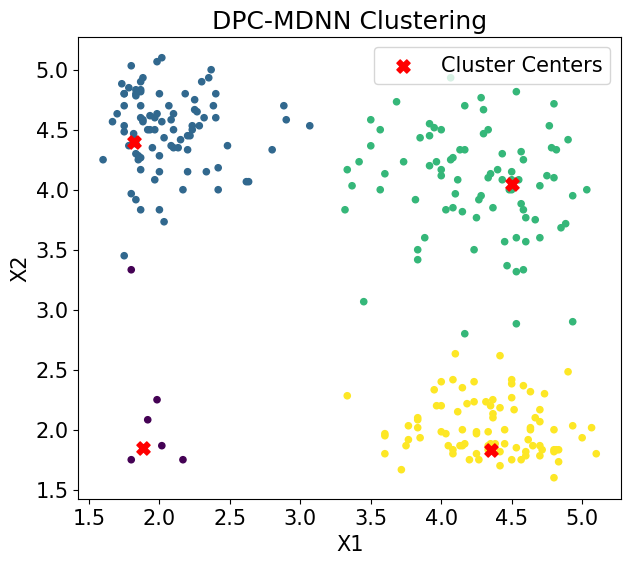

In [16]:
start = time.perf_counter()
DPC_MDNN_labels, DPC_MDNN_det = DPC_MDNN(
    X_dat, n_clusters=n_clusters, manifold_neighbors=5, scale=True,
    return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_MDNN_labels, DPC_MDNN_det["cluster_centers"],
                "DPC-MDNN Clustering")
# record_result("DPC-MDNN", true_labels, DPC_MDNN_labels, elapsed)